In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/omarboukellalfsfl/churn-modelling/Churn_Modelling.csv


## Chargement et aperçu des données

Import du corpus final annoté (`df_final_absa_v4.csv`) et vérification de sa structure.

In [1]:
import pandas as pd

df_absa = pd.read_csv('/kaggle/input/datasets/omarboukellalfsfl/df-final-absa-v4/df_final_absa_v4.csv')

print(f"Shape : {df_absa.shape}")
print(f"\nColonnes : {df_absa.columns.tolist()}")
print(f"\nAperçu :")
print(df_absa.head(3).to_string())

Shape : (102465, 18)

Colonnes : ['avis_id', 'phrase', 'topic', 'topic_keywords', 'aspect', 'aspect_label', 'source_aspect', 'cosine_score', 'hotel_name', 'hotel_city', 'source', 'langue', 'note', 'date_sejour', 'saison', 'type_voyage', 'sentiment', 'score_sentiment']

Aperçu :
   avis_id                                                           phrase  topic                                topic_keywords            aspect        aspect_label source_aspect  cosine_score             hotel_name  hotel_city           source   langue  note date_sejour   saison type_voyage sentiment  score_sentiment
0        2         The bathroom is just reasonable: there is no floor towel      2        clean, bain, chambres, chambre, propre  chambre_proprete  Chambre & Propreté      bertopic           NaN  Ibis Abdelmoumen Casa  Casablanca  tripadvisor.com  Anglais   1.0  2025-11-01  Automne      Couple  positive           0.4573
1        6                         The bathroom floor is wet during bathing  

## Fréquence des aspects mentionnés dans le corpus

Comptage du nombre de phrases rattachées à chaque aspect (volume et pourcentage), 
pour identifier les dimensions les plus discutées par les clients. 
Visualisation sous forme de barres horizontales triées.

Total phrases : 102,465
                                 count   pct
aspect_label                                
Chambre & Propreté               31232  30.5
Personnel                        15185  14.8
Restauration                     12731  12.4
Localisation                     10929  10.7
Service                           8680   8.5
Équipements & Activités           7403   7.2
Expérience & Valeur               6072   5.9
Bruit & Qualité du sommeil        4076   4.0
Confort thermique / Température   2702   2.6
Rapport qualité-prix              2160   2.1
Internet & Wi-Fi                  1295   1.3


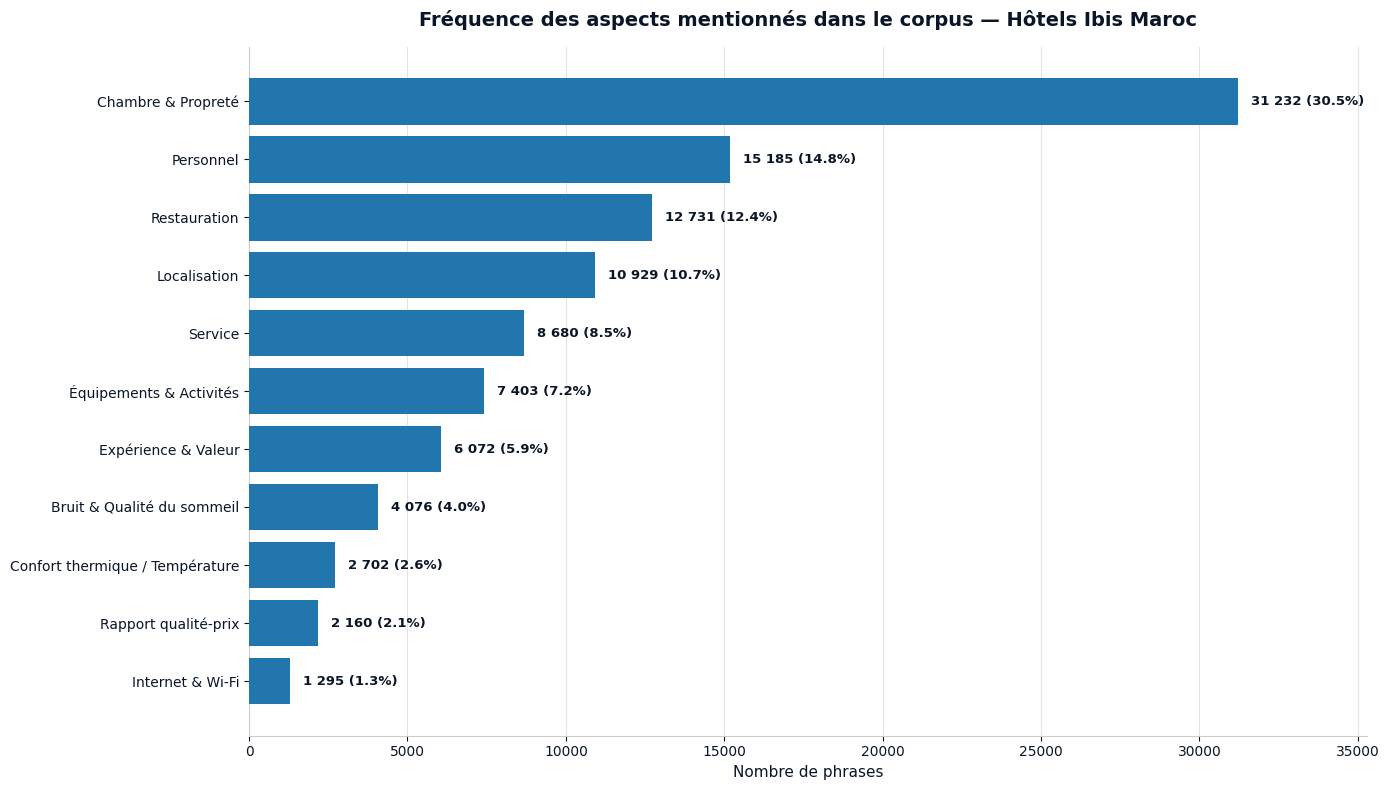

✅ freq_aspects.png


In [2]:
import matplotlib.pyplot as plt
import pandas as pd

# ── Couleurs (thème clair) ───────────────────────────────────
C_BG   = 'white'
C_BARS = '#2176AE'   # bleu plus soutenu sur fond blanc
C_TXT  = '#0A1628'

# ════════════════════════════════════════════════════════════
# 2.1 — FRÉQUENCE DES ASPECTS MENTIONNÉS DANS LE CORPUS
# ════════════════════════════════════════════════════════════
freq  = df_absa['aspect_label'].value_counts()
total = len(df_absa)
pct   = (freq / total * 100).round(1)

print(f"Total phrases : {total:,}")
print(pd.DataFrame({'count': freq, 'pct': pct}).to_string())

# ── Graphique ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor(C_BG)
ax.set_facecolor(C_BG)

# tri croissant pour que le plus grand soit en haut
ordre = freq.sort_values(ascending=True)
pct_o = (ordre / total * 100)

bars = ax.barh(ordre.index, ordre.values, color=C_BARS, zorder=3)

for bar, c, p in zip(bars, ordre.values, pct_o.values):
    ax.text(bar.get_width() + total * 0.004,
            bar.get_y() + bar.get_height() / 2,
            f"{c:,} ({p:.1f}%)".replace(",", " "),
            va='center', color=C_TXT, fontsize=9.5, fontweight='bold')

ax.set_title('Fréquence des aspects mentionnés dans le corpus — Hôtels Ibis Maroc',
             color=C_TXT, fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Nombre de phrases", color=C_TXT, fontsize=11)
ax.tick_params(colors=C_TXT, labelsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['bottom', 'left']].set_color('#CCCCCC')
ax.grid(axis='x', color='#DDDDDD', alpha=0.8)
ax.margins(x=0.13)

for label in ax.get_yticklabels():
    label.set_color(C_TXT)

plt.tight_layout()
plt.savefig('freq_aspects.png', dpi=180, bbox_inches='tight', facecolor=C_BG)
plt.show()
print("✅ freq_aspects.png")

## Distribution globale des sentiments

Part des avis positifs, neutres et négatifs sur l'ensemble du corpus.

Distribution globale des sentiments
  positive   52,252   (51.0%)
  neutral    28,318   (27.6%)
  negative   21,895   (21.4%)
  TOTAL      102,465   (100.0%)


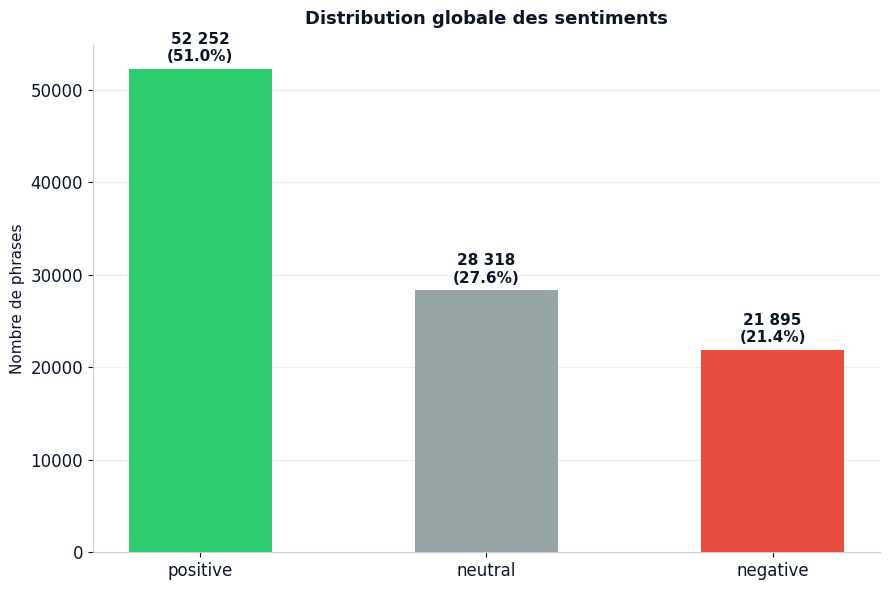

✅ sentiment_distribution.png


In [3]:
import matplotlib.pyplot as plt
import pandas as pd

# ── Données ──────────────────────────────────────────────────
counts = df_absa['sentiment'].value_counts()
total  = len(df_absa)

print("Distribution globale des sentiments")
print("=" * 38)
for sent, n in counts.items():
    print(f"  {sent:<10} {n:>6,}   ({n/total*100:.1f}%)")
print(f"  {'TOTAL':<10} {total:>6,}   (100.0%)")

# ── Couleurs ─────────────────────────────────────────────────
COLORS = {
    'positive': '#2ECC71',
    'negative': '#E74C3C',
    'neutral' : '#95A5A6',
}
labels = counts.index.tolist()
colors = [COLORS.get(l, '#999999') for l in labels]
pcts   = (counts / total * 100).round(1)

# ── Graphique barres uniquement ───────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

bars = ax.bar(labels, counts.values, color=colors, width=0.5, zorder=3)

for bar, n, p in zip(bars, counts.values, pcts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + total * 0.005,
            f"{n:,}\n({p}%)".replace(",", " "),
            ha='center', va='bottom', fontsize=11,
            fontweight='bold', color='#0A1628')

ax.set_title('Distribution globale des sentiments',
             fontsize=13, fontweight='bold', color='#0A1628', pad=15)
ax.set_ylabel('Nombre de phrases', color='#0A1628', fontsize=11)
ax.tick_params(colors='#0A1628', labelsize=12)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['bottom', 'left']].set_color('#CCCCCC')
ax.grid(axis='y', color='#EEEEEE', zorder=0)

plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=180,
            bbox_inches='tight', facecolor='white')
plt.show()
print("✅ sentiment_distribution.png")

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = df_absa.copy()

# 1) Vérifier les libellés exacts (à faire une fois)
print(df['aspect_label'].unique())
print(df['type_voyage'].unique())
print(df['sentiment'].unique())

['Chambre & Propreté' 'Localisation' 'Expérience & Valeur'
 'Confort thermique / Température' 'Bruit & Qualité du sommeil' 'Service'
 'Rapport qualité-prix' 'Personnel' 'Restauration'
 'Équipements & Activités' 'Internet & Wi-Fi']
['Couple' 'Famille' 'Solo' 'Groupe' nan 'Affaires']
['positive' 'negative' 'neutral']


## Aspect × Profil du voyageur

Heatmap de la part d'avis négatifs par aspect et par type de voyageur.

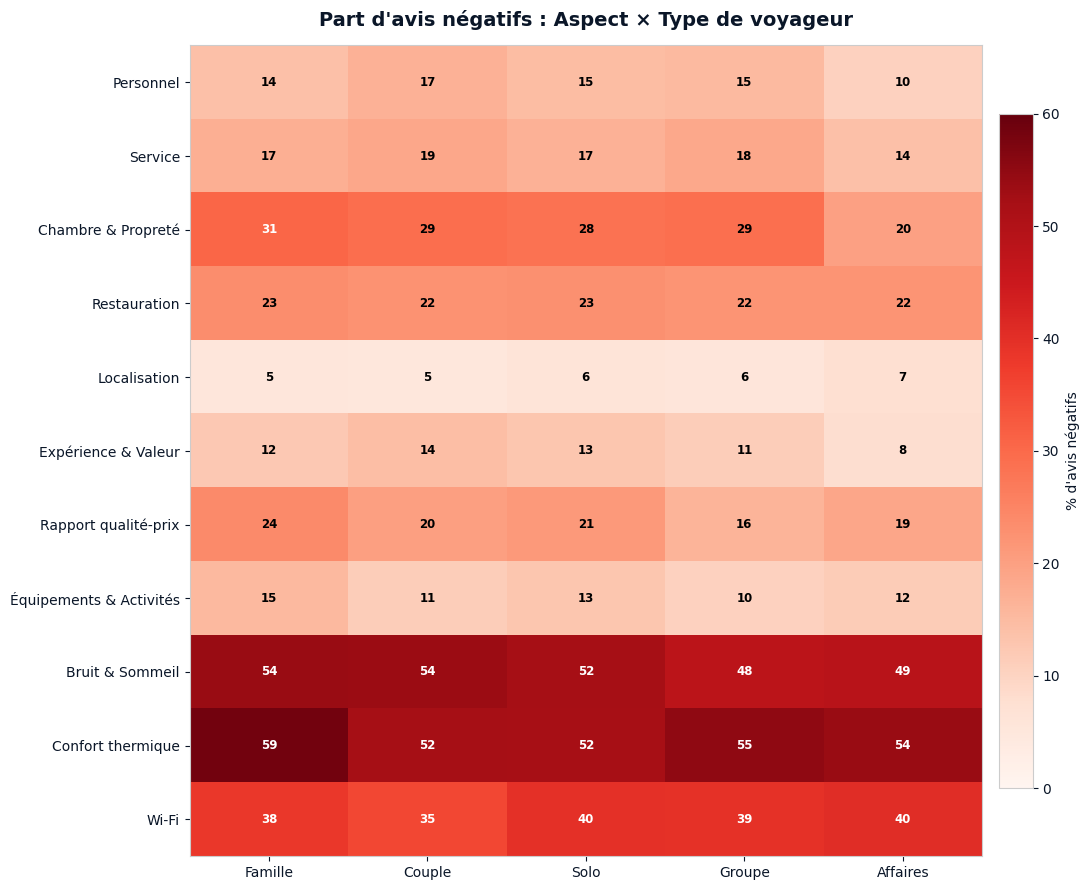

type_voyage       Famille  Couple  Solo  Groupe  Affaires
aspect                                                   
personnel            14.0    17.0  15.0    15.0      10.0
service              17.0    19.0  17.0    18.0      14.0
chambre_proprete     31.0    29.0  28.0    29.0      20.0
restauration         23.0    22.0  23.0    22.0      22.0
localisation          5.0     5.0   6.0     6.0       7.0
experience           12.0    14.0  13.0    11.0       8.0
prix                 24.0    20.0  21.0    16.0      19.0
equipements          15.0    11.0  13.0    10.0      12.0
bruit                54.0    54.0  52.0    48.0      49.0
temperature          59.0    52.0  52.0    55.0      54.0
wifi                 38.0    35.0  40.0    39.0      40.0


In [13]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, warnings
warnings.filterwarnings('ignore')

C_BG='white'; C_TXT='#0A1628'; C_SPINE='#CCCCCC'

plt.rcParams.update({
    'figure.facecolor': C_BG, 'axes.facecolor': C_BG, 'axes.edgecolor': C_SPINE,
    'axes.labelcolor': C_TXT, 'xtick.color': C_TXT, 'ytick.color': C_TXT,
    'text.color': C_TXT, 'font.family': 'DejaVu Sans',
})

ASPECT_ORDER=['personnel','service','chambre_proprete','restauration','localisation',
              'experience','prix','equipements','bruit','temperature','wifi']
ASPECT_LABELS={'personnel':'Personnel','service':'Service','chambre_proprete':'Chambre & Propreté',
    'restauration':'Restauration','localisation':'Localisation','experience':'Expérience & Valeur',
    'prix':'Rapport qualité-prix','equipements':'Équipements & Activités','bruit':'Bruit & Sommeil',
    'temperature':'Confort thermique','wifi':'Wi-Fi'}

def pct_neg(g):
    t = len(g)
    return (g['sentiment']=='negative').sum()/t*100 if t else np.nan

d   = df_absa[df_absa['aspect'].isin(ASPECT_ORDER) & df_absa['type_voyage'].notna()].copy()
hm  = d.groupby(['aspect','type_voyage']).apply(pct_neg).unstack().reindex(index=ASPECT_ORDER)
cnt = d.groupby(['aspect','type_voyage']).size().unstack().reindex(index=ASPECT_ORDER)
hm  = hm.mask(cnt < 15)
ordre = d.groupby('type_voyage').apply(pct_neg).sort_values(ascending=False).index
hm = hm[ordre]

fig, ax = plt.subplots(figsize=(1.4*len(hm.columns)+4, 9), facecolor=C_BG)
ax.set_facecolor(C_BG)
im = ax.imshow(hm.values, cmap=plt.cm.Reds, aspect='auto', vmin=0, vmax=60)

ax.set_xticks(range(len(hm.columns))); ax.set_xticklabels(hm.columns, fontsize=10, rotation=0)
ax.set_yticks(range(len(ASPECT_ORDER))); ax.set_yticklabels([ASPECT_LABELS[a] for a in ASPECT_ORDER], fontsize=10)

for i in range(len(ASPECT_ORDER)):
    for j in range(len(hm.columns)):
        v = hm.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.0f}", ha='center', va='center', fontsize=8.5,
                    fontweight='bold', color='white' if v > 30 else 'black')

cbar = plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
cbar.set_label("% d'avis négatifs", color=C_TXT)
cbar.ax.yaxis.set_tick_params(color=C_TXT)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color=C_TXT)

ax.set_title("Part d'avis négatifs : Aspect × Type de voyageur",
             fontsize=14, fontweight='bold', pad=14, color=C_TXT)
ax.spines[['top','right','bottom','left']].set_color(C_SPINE)

plt.tight_layout()
plt.savefig('viz_neg_aspect_profil.png', dpi=150, bbox_inches='tight', facecolor=C_BG)
plt.show()
print(hm.round(0).to_string())

## Analyse temporelle : pic d'août et évolution annuelle

Deux lectures dans le temps. D'abord l'écart de % d'avis négatifs entre le mois 
d'août et le reste de l'année, par aspect, pour identifier les irritants liés à la 
haute saison. Ensuite l'évolution du Net Sentiment Score de chaque aspect entre 
2024 et 2025, pour mesurer la progression de la satisfaction.

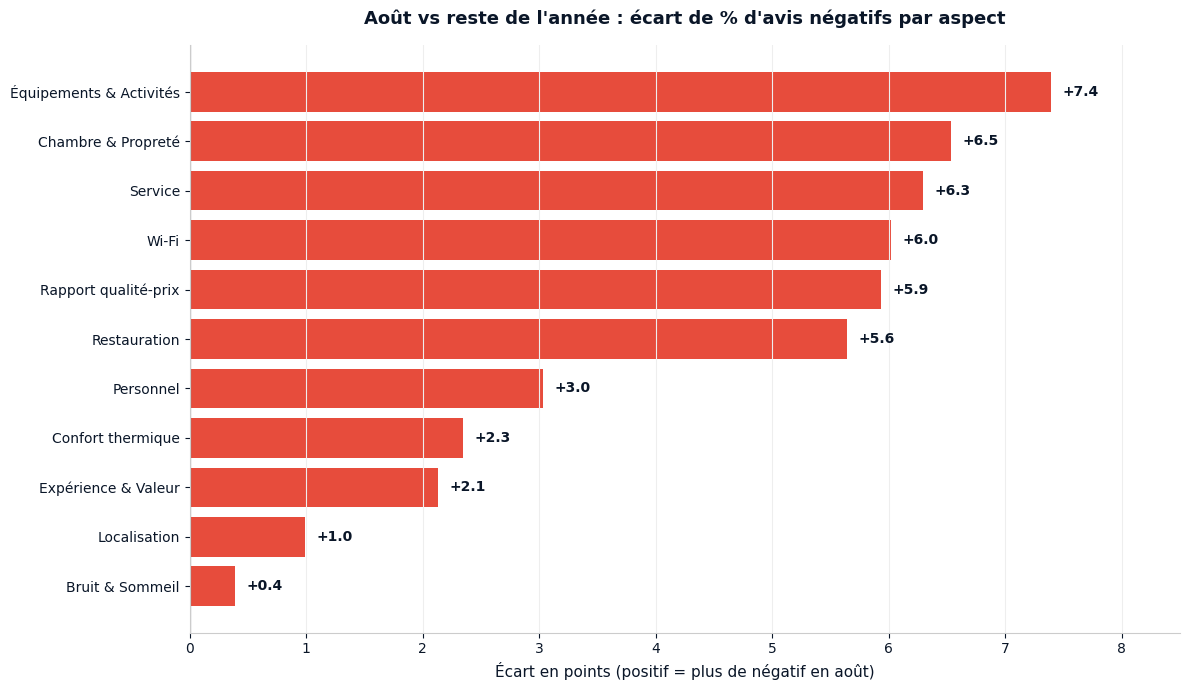

✅ Graphe 1 sauvegardé


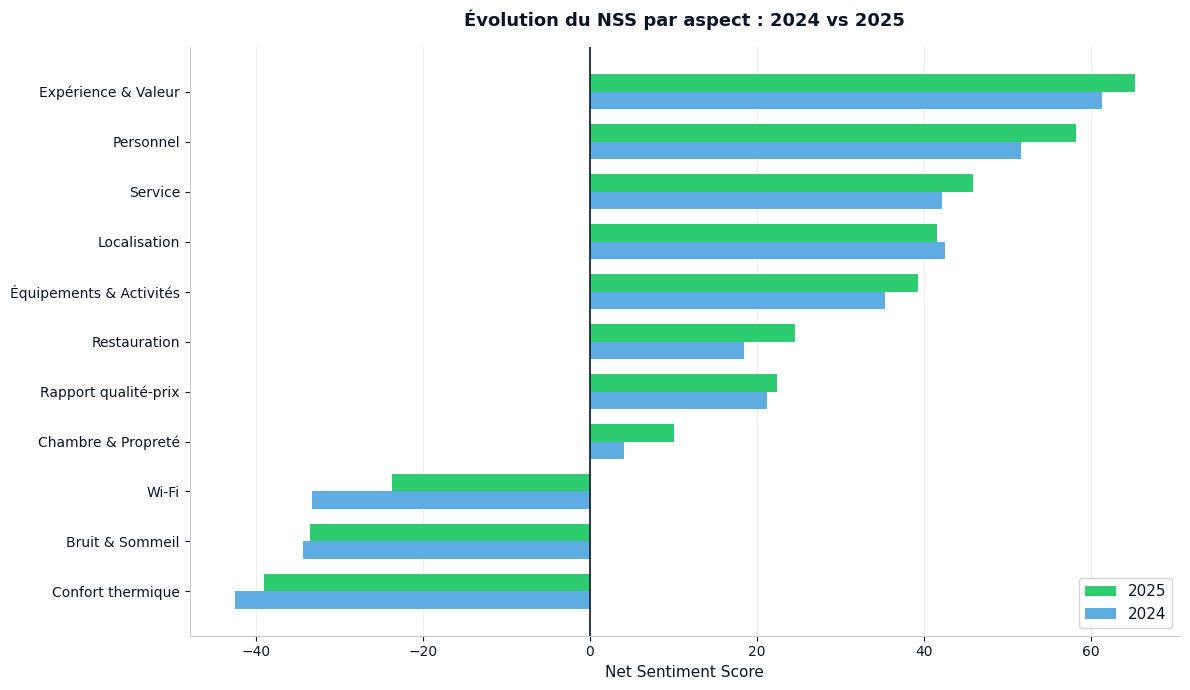

✅ Graphe 2 sauvegardé


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams.update({'font.family': 'DejaVu Sans'})

C_BG  = 'white'; C_TXT = '#0A1628'; C_GRID = '#EEEEEE'; C_SPINE = '#CCCCCC'
C_POS = '#2ECC71'; C_NEG = '#E74C3C'; C_2024 = '#5DADE2'; C_2025 = '#2ECC71'

ASPECT_ORDER = ['personnel','service','chambre_proprete','restauration','localisation',
                'experience','prix','equipements','bruit','temperature','wifi']
ASPECT_LABELS = {
    'personnel':'Personnel','service':'Service','chambre_proprete':'Chambre & Propreté',
    'restauration':'Restauration','localisation':'Localisation','experience':'Expérience & Valeur',
    'prix':'Rapport qualité-prix','equipements':'Équipements & Activités','bruit':'Bruit & Sommeil',
    'temperature':'Confort thermique','wifi':'Wi-Fi',
}

def pct_neg(g):
    t = len(g)
    return (g['sentiment']=='negative').sum()/t*100 if t else np.nan

def nss(grp):
    t = len(grp)
    return ((grp['sentiment']=='positive').sum()-(grp['sentiment']=='negative').sum())/t*100 if t else np.nan

d = df_absa[df_absa['aspect'].isin(ASPECT_ORDER)].copy()
d['mois'] = pd.to_datetime(d['date_sejour'], errors='coerce').dt.month
dm = d[d['mois'].notna()]

# ============================================================
# GRAPHE 1 — Août vs reste de l'année : écart % négatifs
# ============================================================
aout = dm[dm['mois']==8]
base = dm[dm['mois']!=8]
rows = []
for a in ASPECT_ORDER:
    na = pct_neg(aout[aout['aspect']==a])
    nb = pct_neg(base[base['aspect']==a])
    if not np.isnan(na) and not np.isnan(nb):
        rows.append((ASPECT_LABELS[a], na-nb))

ecarts = pd.DataFrame(rows, columns=['aspect','ecart']).sort_values('ecart')

fig, ax = plt.subplots(figsize=(12, 7), facecolor=C_BG)
ax.set_facecolor(C_BG)
colors = [C_NEG if v > 0 else C_POS for v in ecarts['ecart']]
ax.barh(ecarts['aspect'], ecarts['ecart'], color=colors)
ax.axvline(0, color=C_TXT, lw=0.8)

for y, (_, v) in enumerate(ecarts.itertuples(index=False)):
    ax.text(v+(0.1 if v>=0 else -0.1), y, f"{v:+.1f}",
            va='center', ha='left' if v>=0 else 'right',
            color=C_TXT, fontsize=10, fontweight='bold')

ax.set_title("Août vs reste de l'année : écart de % d'avis négatifs par aspect",
             fontsize=13, fontweight='bold', pad=15, color=C_TXT)
ax.set_xlabel("Écart en points (positif = plus de négatif en août)", fontsize=11, color=C_TXT)
ax.margins(x=0.15)
ax.tick_params(colors=C_TXT)
for label in ax.get_xticklabels() + ax.get_yticklabels(): label.set_color(C_TXT)
ax.grid(axis='x', color=C_GRID, lw=0.8)
ax.spines[['top','right']].set_visible(False)
ax.spines[['bottom','left']].set_color(C_SPINE)

plt.tight_layout()
plt.savefig('viz_s5_ecart_aout.png', dpi=150, bbox_inches='tight', facecolor=C_BG)
plt.show()
print("✅ Graphe 1 sauvegardé")

# ============================================================
# GRAPHE 2 — Évolution NSS par aspect : 2024 vs 2025
# ============================================================
d['annee'] = pd.to_datetime(d['date_sejour'], errors='coerce').dt.year

nss_2024 = (d[d['annee']==2024].groupby('aspect').apply(nss)
            .reindex(ASPECT_ORDER).rename('2024'))
nss_2025 = (d[d['annee']==2025].groupby('aspect').apply(nss)
            .reindex(ASPECT_ORDER).rename('2025'))

df_comp = pd.concat([nss_2024, nss_2025], axis=1).dropna(how='all')
# Trier par NSS 2025
df_comp = df_comp.sort_values('2025', ascending=True)
labels  = [ASPECT_LABELS[a] for a in df_comp.index]

y = np.arange(len(df_comp))
w = 0.35

fig, ax = plt.subplots(figsize=(12, 7), facecolor=C_BG)
ax.set_facecolor(C_BG)
ax.barh(y + w/2, df_comp['2025'], w, color=C_2025, label='2025', zorder=3)
ax.barh(y - w/2, df_comp['2024'], w, color=C_2024, label='2024', zorder=3)
ax.axvline(0, color=C_TXT, lw=1.2, zorder=4)

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('Net Sentiment Score', fontsize=11, color=C_TXT)
ax.set_title('Évolution du NSS par aspect : 2024 vs 2025',
             fontsize=13, fontweight='bold', pad=15, color=C_TXT)
ax.legend(fontsize=11, loc='lower right',
          facecolor='white', edgecolor=C_SPINE, labelcolor=C_TXT)
ax.tick_params(colors=C_TXT)
for label in ax.get_xticklabels() + ax.get_yticklabels(): label.set_color(C_TXT)
ax.grid(axis='x', color=C_GRID, lw=0.8, zorder=0)
ax.spines[['top','right']].set_visible(False)
ax.spines[['bottom','left']].set_color(C_SPINE)

plt.tight_layout()
plt.savefig('viz_evolution_2024_2025.png', dpi=150, bbox_inches='tight', facecolor=C_BG)
plt.show()
print("✅ Graphe 2 sauvegardé")

In [16]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, warnings
warnings.filterwarnings('ignore')
C_DARK='#0A1628'; POS='#2ECC71'; NEG='#E74C3C'; GOLD='#F39C12'
plt.rcParams.update({'figure.facecolor':C_DARK,'axes.facecolor':C_DARK,'axes.edgecolor':'#2C3E50',
    'axes.labelcolor':'white','xtick.color':'white','ytick.color':'white','text.color':'white','font.family':'DejaVu Sans'})
ASPECT_ORDER=['personnel','service','chambre_proprete','restauration','localisation',
              'experience','prix','equipements','bruit','temperature','wifi']
ASPECT_LABELS={'personnel':'Personnel','service':'Service','chambre_proprete':'Chambre & Propreté',
    'restauration':'Restauration','localisation':'Localisation','experience':'Expérience & Valeur',
    'prix':'Rapport qualité-prix','equipements':'Équipements & Activités','bruit':'Bruit & Sommeil',
    'temperature':'Confort thermique','wifi':'Wi-Fi'}
ASPECTS6=['bruit','temperature','wifi','chambre_proprete','restauration','prix']
def nss(g):     t=len(g); return ((g['sentiment']=='positive').sum()-(g['sentiment']=='negative').sum())/t*100 if t else np.nan
def pct_neg(g): t=len(g); return (g['sentiment']=='negative').sum()/t*100 if t else np.nan

d = df_absa.copy()

# Ordre des saisons (adapte si tes libellés diffèrent)
SAISON_ORDRE = ['Hiver','Printemps','Été','Automne']
saisons = [s for s in SAISON_ORDRE if s in d['saison'].unique()] or sorted(d['saison'].dropna().unique())

print("Saisons :", d['saison'].unique())
print("Aperçu date_sejour :", d['date_sejour'].dropna().head(3).tolist())

Saisons : ['Automne' 'Été' 'Printemps' 'Hiver' 'Inconnu']
Aperçu date_sejour : ['2025-11-01', '2025-11-01', '2025-11-01']


## Affaires vs Loisirs : le sentiment par aspect

Comparaison du Net Sentiment Score de chaque aspect entre les deux grands segments 
de clientèle : voyageurs d'affaires et voyageurs de loisirs (couple, famille, solo, 
groupe regroupés). Met en évidence les écarts de perception entre les deux profils, 
notamment sur la chambre et la propreté.

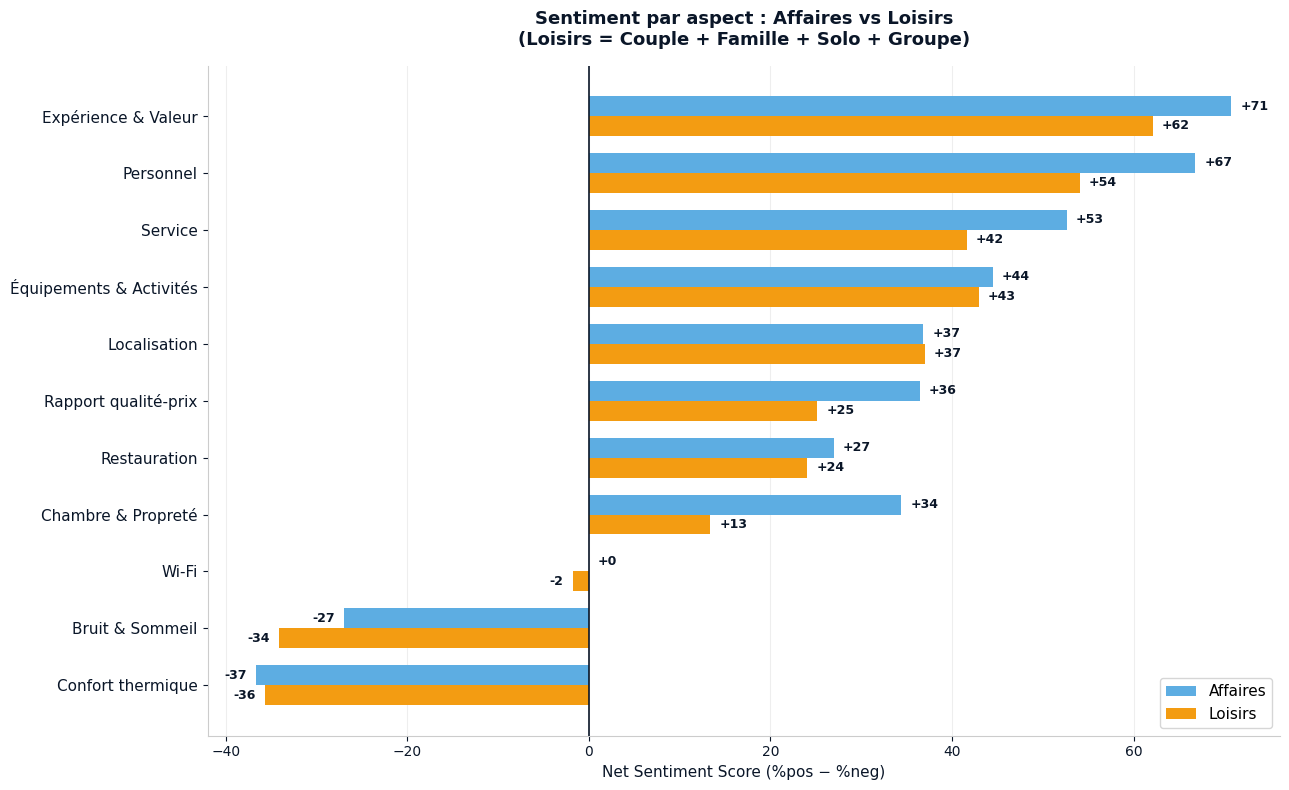

✅ Graphe 1 sauvegardé


In [31]:
df_aff = d[d['profil']=='Affaires'].groupby('aspect').apply(nss).reindex(ORDRE_AFF_LOI).rename('Affaires')
df_loi = d[d['profil']=='Loisirs' ].groupby('aspect').apply(nss).reindex(ORDRE_AFF_LOI).rename('Loisirs')
df_comp = pd.concat([df_aff, df_loi], axis=1)

# Trier par moyenne NSS décroissante (positif en haut, négatif en bas)
df_comp['_mean'] = df_comp.mean(axis=1)
df_comp = df_comp.sort_values('_mean', ascending=True).drop(columns='_mean')
labels  = [ASPECT_LABELS[a] for a in df_comp.index]

y = np.arange(len(df_comp))
w = 0.35

fig, ax = plt.subplots(figsize=(13, 8), facecolor=C_BG)
ax.set_facecolor(C_BG)
bars_a = ax.barh(y + w/2, df_comp['Affaires'], w, color=C_AFF, label='Affaires', zorder=3)
bars_l = ax.barh(y - w/2, df_comp['Loisirs'],  w, color=C_LOI, label='Loisirs',  zorder=3)
ax.axvline(0, color=C_TXT, lw=1.2, zorder=4)

for bar, v in zip(bars_a, df_comp['Affaires']):
    if not np.isnan(v):
        ax.text(v+(1 if v>=0 else -1), bar.get_y()+bar.get_height()/2,
                f'{v:+.0f}', va='center', ha='left' if v>=0 else 'right',
                fontsize=9, fontweight='bold', color=C_TXT)

for bar, v in zip(bars_l, df_comp['Loisirs']):
    if not np.isnan(v):
        ax.text(v+(1 if v>=0 else -1), bar.get_y()+bar.get_height()/2,
                f'{v:+.0f}', va='center', ha='left' if v>=0 else 'right',
                fontsize=9, fontweight='bold', color=C_TXT)

ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=11)
ax.set_xlabel('Net Sentiment Score (%pos − %neg)', fontsize=11, color=C_TXT)
ax.set_title('Sentiment par aspect : Affaires vs Loisirs\n'
             '(Loisirs = Couple + Famille + Solo + Groupe)',
             fontsize=13, fontweight='bold', pad=15, color=C_TXT)
ax.legend(fontsize=11, loc='lower right', facecolor='white', edgecolor=C_SPINE)
ax.tick_params(colors=C_TXT)
for label in ax.get_xticklabels() + ax.get_yticklabels(): label.set_color(C_TXT)
ax.grid(axis='x', color=C_GRID, lw=0.8, zorder=0)
ax.spines[['top','right']].set_visible(False)
ax.spines[['bottom','left']].set_color(C_SPINE)
plt.tight_layout()
plt.savefig('viz_affaires_vs_loisirs.png', dpi=150, bbox_inches='tight', facecolor=C_BG)
plt.show()
print("✅ Graphe 1 sauvegardé")

## Aspect × Saison

Net Sentiment Score par aspect et par saison (heatmap).

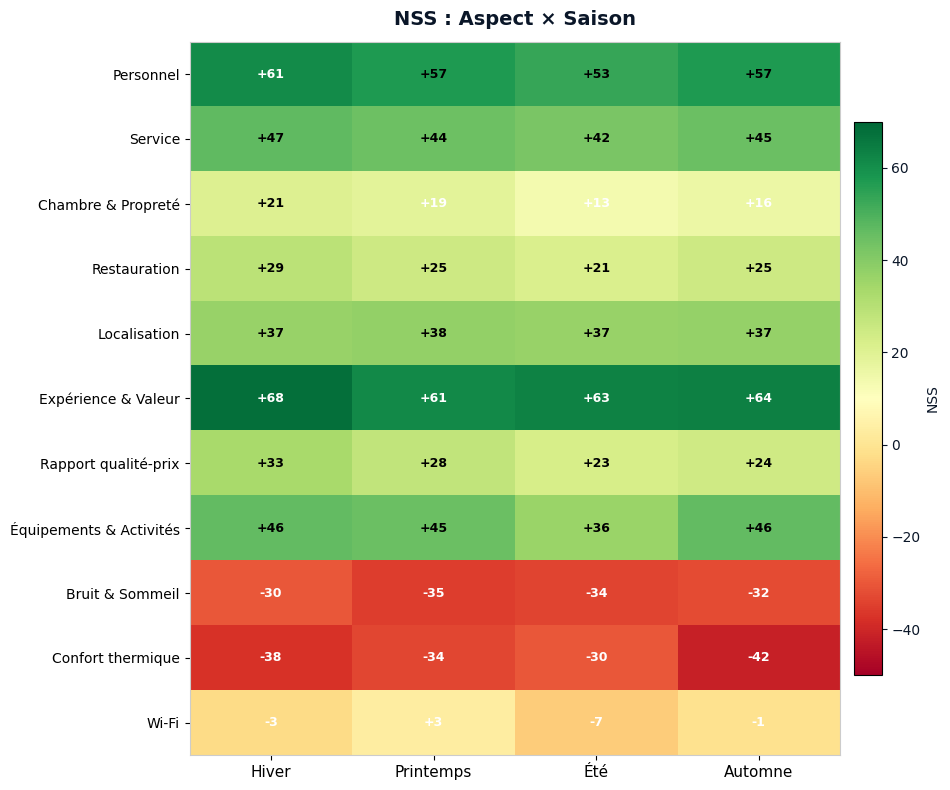

saison            Hiver  Printemps   Été  Automne
aspect                                           
personnel          61.0       57.0  53.0     57.0
service            47.0       44.0  42.0     45.0
chambre_proprete   21.0       19.0  13.0     16.0
restauration       29.0       25.0  21.0     25.0
localisation       37.0       38.0  37.0     37.0
experience         68.0       61.0  63.0     64.0
prix               33.0       28.0  23.0     24.0
equipements        46.0       45.0  36.0     46.0
bruit             -30.0      -35.0 -34.0    -32.0
temperature       -38.0      -34.0 -30.0    -42.0
wifi               -3.0        3.0  -7.0     -1.0


In [18]:
# ===== VIZ 1 — Heatmap NSS : aspect × saison =====
da  = d[d['aspect'].isin(ASPECT_ORDER) & d['saison'].notna()]
hm  = da.groupby(['aspect','saison']).apply(nss).unstack().reindex(index=ASPECT_ORDER)[saisons]
cnt = da.groupby(['aspect','saison']).size().unstack().reindex(index=ASPECT_ORDER)[saisons]
hm  = hm.mask(cnt < 15)

fig, ax = plt.subplots(figsize=(1.4*len(saisons)+4, 8), facecolor='white')
ax.set_facecolor('white')
im = ax.imshow(hm.values, cmap=plt.cm.RdYlGn, aspect='auto', vmin=-50, vmax=70)

ax.set_xticks(range(len(saisons))); ax.set_xticklabels(saisons, fontsize=11)
ax.set_yticks(range(len(ASPECT_ORDER))); ax.set_yticklabels([ASPECT_LABELS[a] for a in ASPECT_ORDER], fontsize=10)

for i in range(len(ASPECT_ORDER)):
    for j in range(len(saisons)):
        v = hm.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:+.0f}", ha='center', va='center', fontsize=9,
                    fontweight='bold', color='black' if 20 < v < 60 else 'white')

cbar = plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
cbar.set_label('NSS', color='#0A1628')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#0A1628')
cbar.ax.yaxis.set_tick_params(color='#0A1628')

ax.set_title('NSS : Aspect × Saison', fontsize=14, fontweight='bold', pad=12, color='#0A1628')
ax.spines[['top','right','bottom','left']].set_color('#CCCCCC')

plt.tight_layout()
plt.savefig('viz_s1_nss_aspect_saison.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(hm.round(0).to_string())

## Part d'avis négatifs par mois

Évolution mensuelle des avis négatifs — mise en évidence du pic d'août.

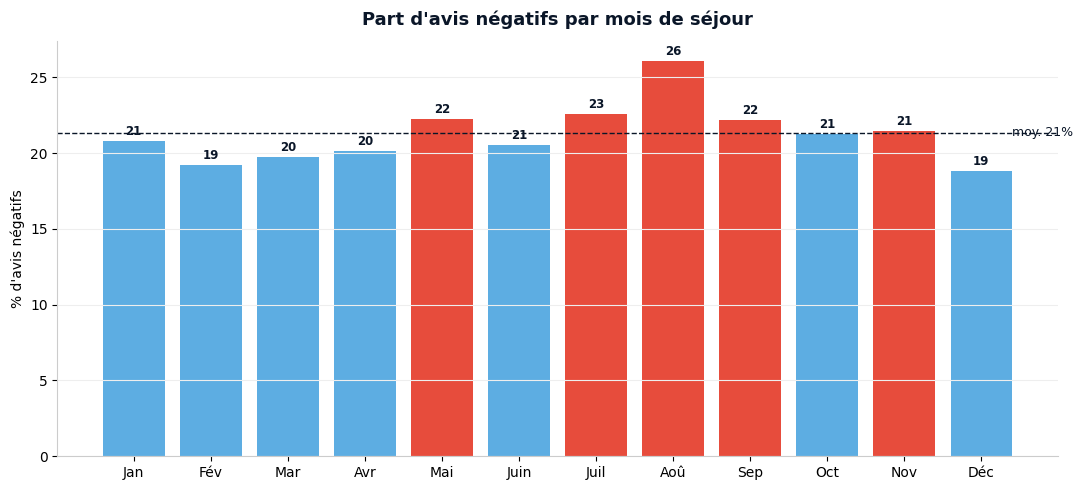

mois
1     20.8
2     19.2
3     19.7
4     20.1
5     22.3
6     20.5
7     22.6
8     26.1
9     22.2
10    21.3
11    21.5
12    18.8


In [20]:
# ===== VIZ 3 — % négatifs global par mois =====
d['mois'] = pd.to_datetime(d['date_sejour'], errors='coerce').dt.month
dm = d[d['mois'].notna()]
MOIS = ['Jan','Fév','Mar','Avr','Mai','Juin','Juil','Aoû','Sep','Oct','Nov','Déc']
serie = dm.groupby('mois').apply(pct_neg).reindex(range(1,13))

fig, ax = plt.subplots(figsize=(11, 5), facecolor='white')
ax.set_facecolor('white')
moy = pct_neg(dm)
colors = [NEG if v > moy else '#5DADE2' for v in serie]
ax.bar(range(1,13), serie.values, color=colors)
ax.axhline(moy, color='#0A1628', ls='--', lw=1)
ax.text(12.4, moy, f"moy. {moy:.0f}%", color='#0A1628', va='center', fontsize=9)
ax.set_xticks(range(1,13))
ax.set_xticklabels(MOIS)
for label in ax.get_xticklabels(): label.set_color('black')
for label in ax.get_yticklabels(): label.set_color('black')

for x, v in zip(range(1,13), serie.values):
    if not np.isnan(v):
        ax.text(x, v+0.4, f"{v:.0f}", ha='center', color='#0A1628', fontsize=8.5, fontweight='bold')

ax.set_title("Part d'avis négatifs par mois de séjour", fontsize=13, fontweight='bold', pad=12, color='#0A1628')
ax.set_ylabel("% d'avis négatifs", color='black')
ax.tick_params(colors='black')
ax.grid(axis='y', color='#EEEEEE', lw=0.8)
ax.spines[['top','right']].set_visible(False)
ax.spines[['bottom','left']].set_color('#CCCCCC')

plt.tight_layout()
plt.savefig('viz_s3_neg_par_mois.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(serie.round(1).to_string())

## Confort thermique par mois

Part d'avis négatifs sur la température, mois par mois — un irritant présent toute l'année.

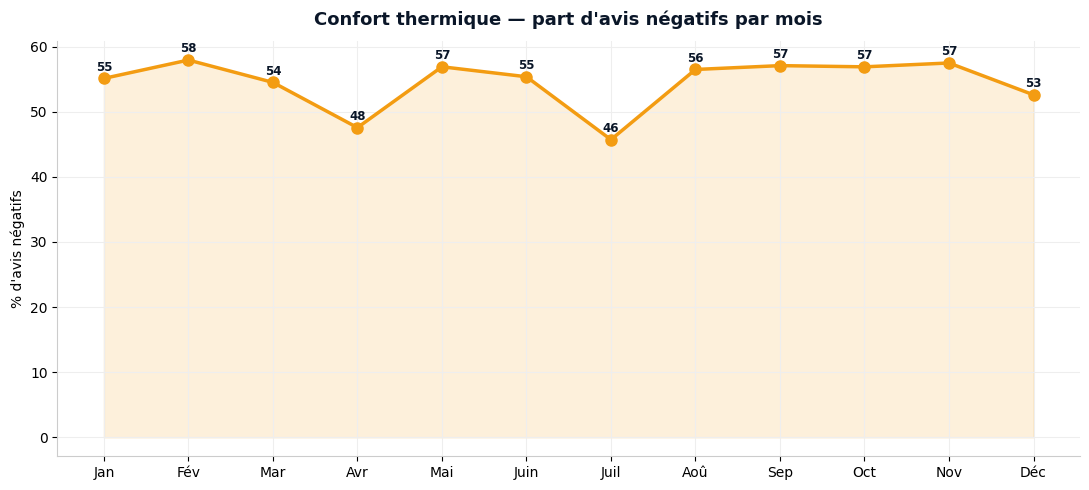

mois
1     55.1
2     57.9
3     54.5
4     47.5
5     56.9
6     55.4
7     45.7
8     56.5
9     57.1
10    56.9
11    57.5
12    52.6


In [21]:
# ===== VIZ 4 — Confort thermique : % négatifs par mois =====
dt = dm[dm['aspect']=='temperature']
st = dt.groupby('mois').apply(pct_neg).reindex(range(1,13))

fig, ax = plt.subplots(figsize=(11, 5), facecolor='white')
ax.set_facecolor('white')
ax.plot(range(1,13), st.values, marker='o', color=GOLD, lw=2.5, markersize=8)
ax.fill_between(range(1,13), st.values, color=GOLD, alpha=0.15)
ax.set_xticks(range(1,13))
ax.set_xticklabels(MOIS)
for label in ax.get_xticklabels(): label.set_color('black')
for label in ax.get_yticklabels(): label.set_color('black')

for x, v in zip(range(1,13), st.values):
    if not np.isnan(v):
        ax.text(x, v+1.2, f"{v:.0f}", ha='center', color='#0A1628', fontsize=8.5, fontweight='bold')

ax.set_title("Confort thermique  part d'avis négatifs par mois",
             fontsize=13, fontweight='bold', pad=12, color='#0A1628')
ax.set_ylabel("% d'avis négatifs", color='black')
ax.tick_params(colors='black')
ax.grid(color='#EEEEEE', lw=0.8)
ax.spines[['top','right']].set_visible(False)
ax.spines[['bottom','left']].set_color('#CCCCCC')

plt.tight_layout()
plt.savefig('viz_s4_temp_par_mois.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(st.round(1).to_string())

## Sentiment et NSS par aspect

Répartition positif/neutre/négatif et Net Sentiment Score pour chacun des 11 aspects.

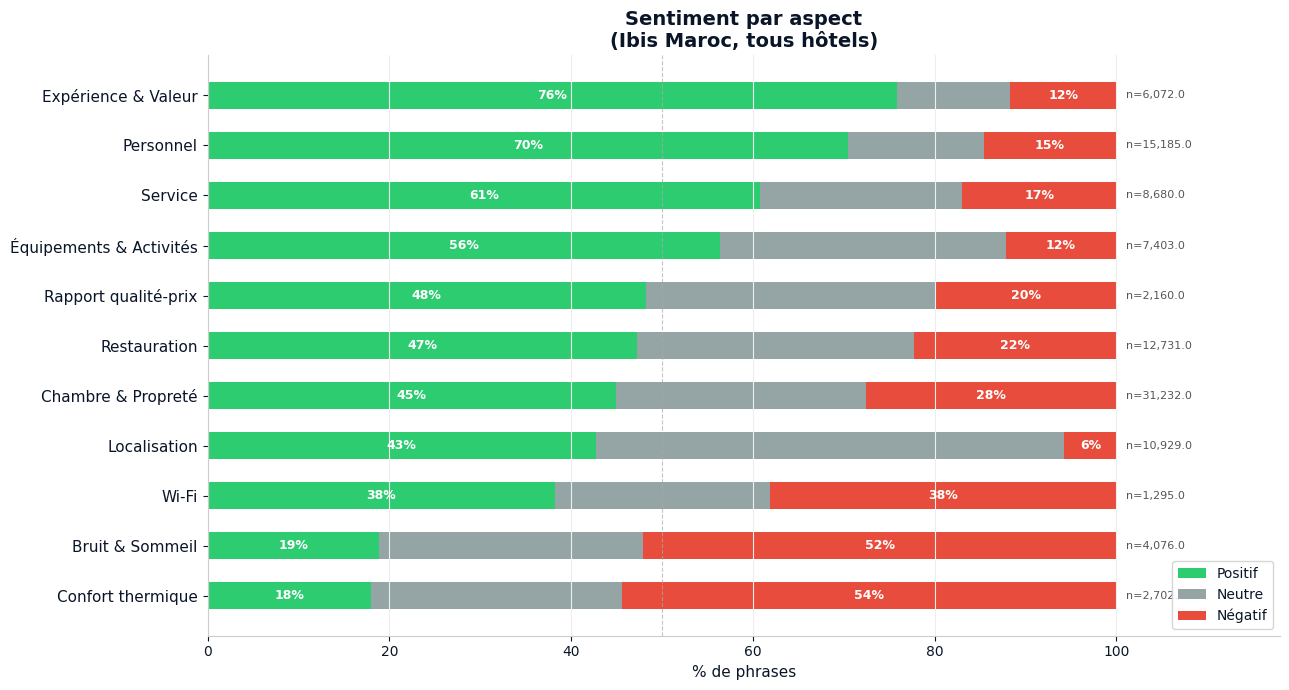

✅ VIZ 3 sauvegardée


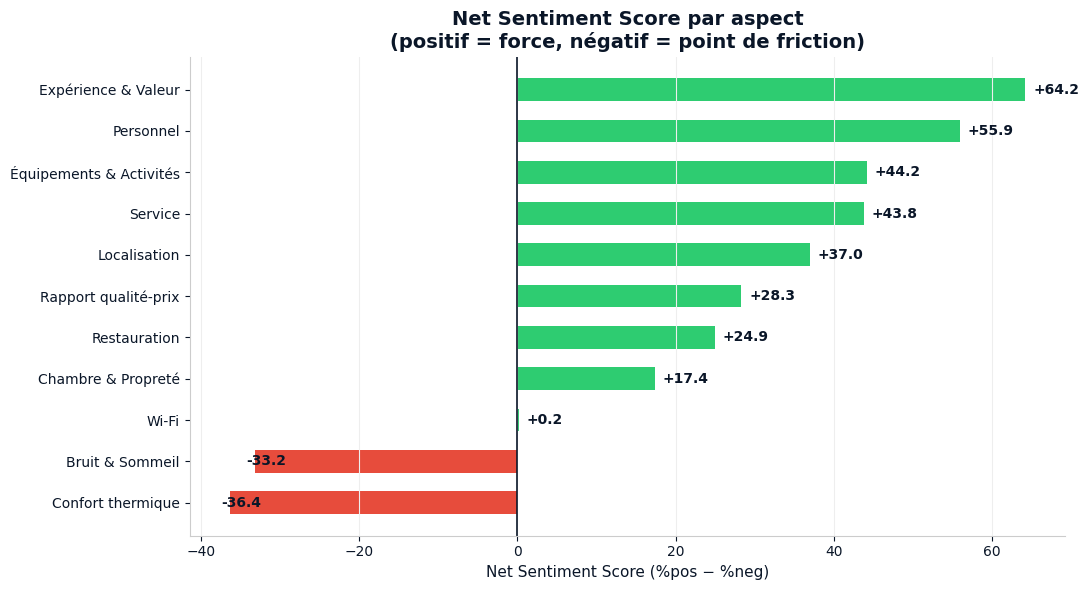

✅ VIZ 4 sauvegardée

Net Sentiment Score par aspect :
sentiment               NSS  total
aspect                            
temperature      -36.380459   2702
bruit            -33.218842   4076
wifi               0.154440   1295
chambre_proprete  17.366803  31232
restauration      24.899851  12731
prix              28.287037   2160
localisation      36.965871  10929
service           43.755760   8680
equipements       44.171282   7403
personnel         55.864340  15185
experience        64.163373   6072


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import PercentFormatter
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIG GLOBALE
# ============================================================
C_BG     = 'white'
C_TXT    = '#0A1628'
C_GRID   = '#EEEEEE'
C_SPINE  = '#CCCCCC'
C_POS    = '#2ECC71'
C_NEG    = '#E74C3C'
C_NEU    = '#95A5A6'
C_ACCENT = '#3498DB'
C_GOLD   = '#F39C12'

ASPECT_ORDER = [
    'personnel', 'service', 'chambre_proprete', 'restauration',
    'localisation', 'experience', 'prix', 'equipements',
    'bruit', 'temperature', 'wifi'
]
ASPECT_LABELS = {
    'personnel'        : 'Personnel',
    'service'          : 'Service',
    'chambre_proprete' : 'Chambre & Propreté',
    'restauration'     : 'Restauration',
    'localisation'     : 'Localisation',
    'experience'       : 'Expérience & Valeur',
    'prix'             : 'Rapport qualité-prix',
    'equipements'      : 'Équipements & Activités',
    'bruit'            : 'Bruit & Sommeil',
    'temperature'      : 'Confort thermique',
    'wifi'             : 'Wi-Fi',
}

plt.rcParams.update({
    'figure.facecolor' : C_BG,
    'axes.facecolor'   : C_BG,
    'axes.edgecolor'   : C_SPINE,
    'axes.labelcolor'  : C_TXT,
    'xtick.color'      : C_TXT,
    'ytick.color'      : C_TXT,
    'text.color'       : C_TXT,
    'font.family'      : 'DejaVu Sans',
    'legend.facecolor' : 'white',
    'legend.edgecolor' : C_SPINE,
})

df_absa['annee'] = pd.to_datetime(df_absa['date_sejour'], errors='coerce').dt.year
df_absa = df_absa.dropna(subset=['aspect', 'sentiment'])

# ============================================================
# VIZ 3 — SENTIMENT PAR ASPECT (stacked horizontal bar)
# ============================================================
df_asp   = df_absa[df_absa['aspect'].isin(ASPECT_ORDER)].copy()
pivot_asp = (
    df_asp.groupby(['aspect', 'sentiment'])
    .size().unstack(fill_value=0)
)
pivot_asp['total'] = pivot_asp.sum(axis=1)
for col in ['positive', 'neutral', 'negative']:
    if col not in pivot_asp.columns: pivot_asp[col] = 0
pivot_asp['pct_pos'] = pivot_asp['positive'] / pivot_asp['total'] * 100
pivot_asp['pct_neg'] = pivot_asp['negative'] / pivot_asp['total'] * 100
pivot_asp['pct_neu'] = pivot_asp['neutral']  / pivot_asp['total'] * 100
pivot_asp = pivot_asp.loc[[a for a in ASPECT_ORDER if a in pivot_asp.index]]
pivot_asp = pivot_asp.sort_values('pct_pos', ascending=True)

fig, ax = plt.subplots(figsize=(13, 7), facecolor=C_BG)
ax.set_facecolor(C_BG)
y_pos      = range(len(pivot_asp))
labels_asp = [ASPECT_LABELS[a] for a in pivot_asp.index]

ax.barh(y_pos, pivot_asp['pct_pos'], color=C_POS, label='Positif', height=0.55)
ax.barh(y_pos, pivot_asp['pct_neu'], left=pivot_asp['pct_pos'],
        color=C_NEU, label='Neutre', height=0.55)
ax.barh(y_pos, pivot_asp['pct_neg'],
        left=pivot_asp['pct_pos'] + pivot_asp['pct_neu'],
        color=C_NEG, label='Négatif', height=0.55)

for i, (idx, row) in enumerate(pivot_asp.iterrows()):
    ax.text(row['pct_pos']/2, i, f"{row['pct_pos']:.0f}%",
            va='center', ha='center', fontsize=9, fontweight='bold', color='white')
    ax.text(row['pct_pos'] + row['pct_neu'] + row['pct_neg']/2, i,
            f"{row['pct_neg']:.0f}%",
            va='center', ha='center', fontsize=9, fontweight='bold', color='white')
    ax.text(101, i, f"n={row['total']:,}", va='center', fontsize=8, color='#555555')

ax.set_yticks(list(y_pos))
ax.set_yticklabels(labels_asp, fontsize=11)
ax.set_xlim(0, 118)
ax.set_xlabel('% de phrases', fontsize=11)
ax.set_title('Sentiment par aspect\n(Ibis Maroc, tous hôtels)',
             fontsize=14, fontweight='bold', color=C_TXT)
ax.legend(loc='lower right', fontsize=10)
ax.axvline(50, color='#AAAAAA', linewidth=0.8, linestyle='--', alpha=0.7)
ax.grid(axis='x', color=C_GRID, linewidth=0.8)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['bottom', 'left']].set_color(C_SPINE)
plt.tight_layout()
plt.savefig('viz3_sentiment_aspect.png', dpi=150, bbox_inches='tight', facecolor=C_BG)
plt.show()
print("✅ VIZ 3 sauvegardée")

# ============================================================
# VIZ 4 — NET SENTIMENT SCORE PAR ASPECT
# ============================================================
pivot_asp['NSS']     = pivot_asp['pct_pos'] - pivot_asp['pct_neg']
pivot_asp_nss        = pivot_asp.sort_values('NSS', ascending=True)

fig, ax = plt.subplots(figsize=(11, 6), facecolor=C_BG)
ax.set_facecolor(C_BG)
colors_nss = [C_POS if v >= 0 else C_NEG for v in pivot_asp_nss['NSS']]
bars = ax.barh([ASPECT_LABELS[a] for a in pivot_asp_nss.index],
               pivot_asp_nss['NSS'], color=colors_nss, height=0.55)
ax.axvline(0, color=C_TXT, linewidth=1.2)
ax.set_xlabel('Net Sentiment Score (%pos − %neg)', fontsize=11)
ax.set_title('Net Sentiment Score par aspect\n(positif = force, négatif = point de friction)',
             fontsize=14, fontweight='bold', color=C_TXT)

for bar, val in zip(bars, pivot_asp_nss['NSS']):
    offset = 1 if val >= 0 else -1
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:+.1f}', va='center', fontsize=10, fontweight='bold', color=C_TXT)

ax.grid(axis='x', color=C_GRID, linewidth=0.8)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['bottom', 'left']].set_color(C_SPINE)
plt.tight_layout()
plt.savefig('viz4_nss_aspect.png', dpi=150, bbox_inches='tight', facecolor=C_BG)
plt.show()
print("✅ VIZ 4 sauvegardée")
print("\nNet Sentiment Score par aspect :")
print(pivot_asp_nss[['NSS', 'total']].to_string())

## Approfondissement : priorisation, causes, plateformes et fiabilité

Analyses complémentaires par aspect : matrice de priorisation (volume × 
satisfaction), exploration qualitative des causes (mots-clés et verbatims des 
irritants), comparaison du sentiment selon la plateforme, et fiabilité de la 
classification par aspect.

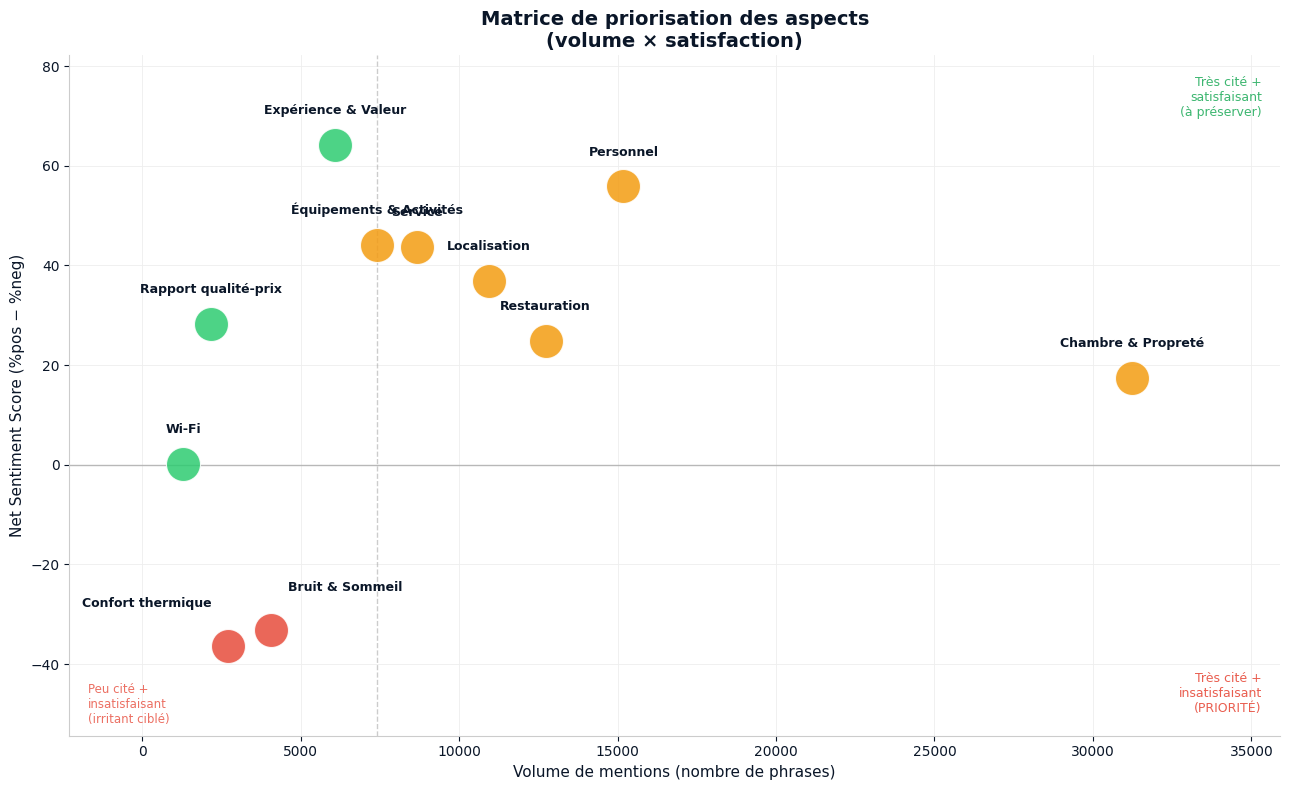

✅ matrice de priorisation
sentiment         total  freq_pct   NSS
aspect                                 
temperature        2702       2.6 -36.4
bruit              4076       4.0 -33.2
wifi               1295       1.3   0.2
chambre_proprete  31232      30.5  17.4
restauration      12731      12.4  24.9
prix               2160       2.1  28.3
localisation      10929      10.7  37.0
service            8680       8.5  43.8
equipements        7403       7.2  44.2
personnel         15185      14.8  55.9
experience         6072       5.9  64.2

ASPECT : Bruit & Sommeil
Mots-clés (négatif) : ['noisy', 'noise', 'bruyant', 'bruit', 'nuit', 'road', 'facing', 'bruyantes', 'rooms facing', 'window', 'windows', 'open']
Verbatims négatifs :
   •  C'est dommage car l'endroit est plus calme.
   •  dommage que le réceptionniste de nuit soit si hautain et désagréable.
   •  au Maroc laisser 40 d'un smic local pour juste dormir... dommage
Verbatims positifs :
   •  Accueil parfait en pleine nuit.
   •  

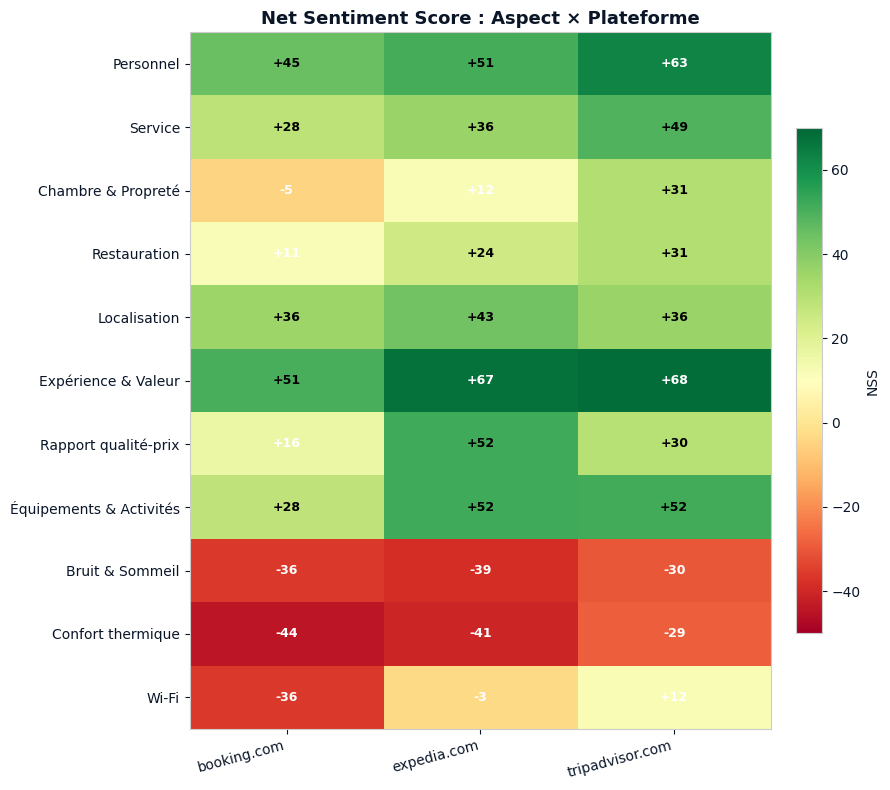

✅ aspect × plateforme
source            booking.com  expedia.com  tripadvisor.com
aspect                                                     
personnel                44.9         51.1             62.6
service                  28.5         36.0             49.3
chambre_proprete         -4.5         12.2             30.9
restauration             11.5         24.5             30.9
localisation             35.7         43.4             36.0
experience               50.7         67.4             68.5
prix                     15.8         51.7             29.8
equipements              28.3         52.1             51.5
bruit                   -36.3        -38.7            -30.0
temperature             -44.1        -40.5            -28.8
wifi                    -36.1         -3.4             12.2


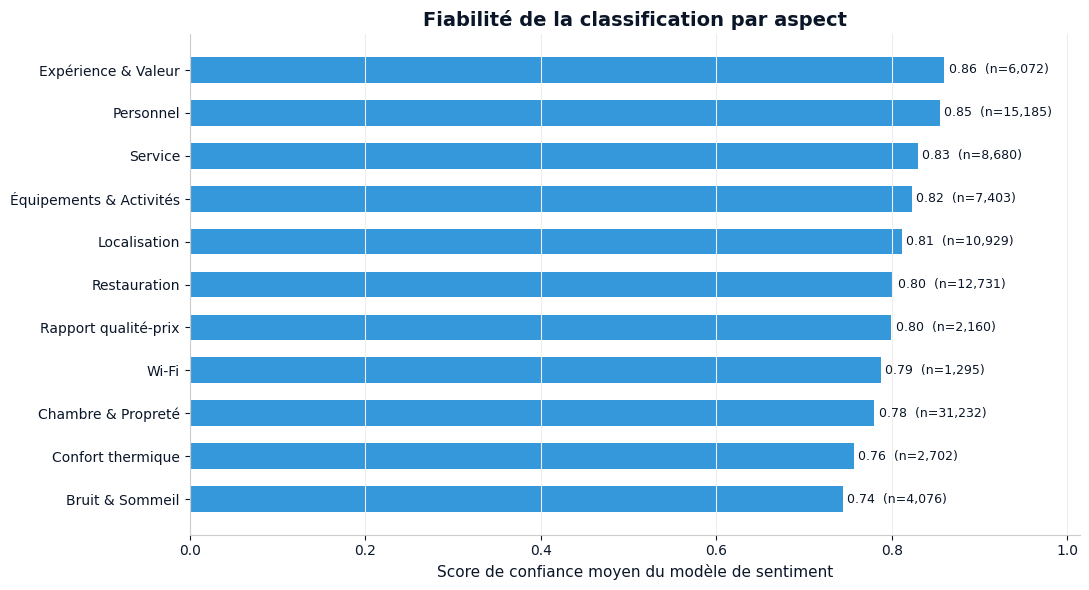

✅ fiabilité par aspect
                  conf_moy      n
aspect                           
bruit                0.744   4076
temperature          0.757   2702
chambre_proprete     0.780  31232
wifi                 0.788   1295
prix                 0.799   2160
restauration         0.802  12731
localisation         0.812  10929
equipements          0.823   7403
service              0.830   8680
personnel            0.855  15185
experience           0.860   6072


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

C_BG='white'; C_TXT='#0A1628'; C_GRID='#EEEEEE'; C_SPINE='#CCCCCC'
C_POS='#2ECC71'; C_NEG='#E74C3C'; C_NEU='#95A5A6'; C_ACCENT='#3498DB'; C_GOLD='#F39C12'

plt.rcParams.update({
    'figure.facecolor': C_BG, 'axes.facecolor': C_BG, 'axes.edgecolor': C_SPINE,
    'axes.labelcolor': C_TXT, 'xtick.color': C_TXT, 'ytick.color': C_TXT,
    'text.color': C_TXT, 'font.family': 'DejaVu Sans',
    'legend.facecolor': 'white', 'legend.edgecolor': C_SPINE,
})

# Base : pivot aspect
df_a = df_absa[df_absa['aspect'].isin(ASPECT_ORDER)].copy()
piv = df_a.groupby(['aspect','sentiment']).size().unstack(fill_value=0)
for c in ['positive','neutral','negative']:
    if c not in piv: piv[c]=0
piv['total']=piv.sum(axis=1)
piv['pct_pos']=piv['positive']/piv['total']*100
piv['pct_neg']=piv['negative']/piv['total']*100
piv['NSS']=piv['pct_pos']-piv['pct_neg']
piv['freq_pct']=piv['total']/piv['total'].sum()*100

# ============================================================
# A — MATRICE DE PRIORISATION : Fréquence × NSS
# ============================================================
fig, ax = plt.subplots(figsize=(13, 8), facecolor=C_BG)
ax.set_facecolor(C_BG)
x = piv['total']; y = piv['NSS']
x_split = x.median()
xpad = (x.max() - x.min()) * 0.12
ypad = 18
ax.set_xlim(x.min() - xpad, x.max() + xpad * 1.3)
ax.set_ylim(y.min() - ypad, y.max() + ypad)
ax.axhline(0, color='#AAAAAA', lw=1, alpha=0.8)
ax.axvline(x_split, color='#AAAAAA', lw=1, ls='--', alpha=0.6)

label_offsets = {
    'temperature': (-12, 26, 'right', 'bottom'),
    'bruit':       ( 12, 26, 'left',  'bottom'),
}

for asp in piv.index:
    xi, yi = piv.loc[asp, 'total'], piv.loc[asp, 'NSS']
    col = C_NEG if yi < 0 else (C_GOLD if xi >= x_split else C_POS)
    ax.scatter(xi, yi, s=600, color=col, alpha=0.85, edgecolor='white', linewidth=0.8, zorder=3)
    if asp in label_offsets:
        dx, dy, ha, va = label_offsets[asp]
    else:
        dx, dy = 0, (20 if yi >= 0 else -22)
        ha, va = 'center', ('bottom' if yi >= 0 else 'top')
    ax.annotate(ASPECT_LABELS[asp], (xi, yi), fontsize=9, color=C_TXT,
                ha=ha, va=va, xytext=(dx, dy), textcoords='offset points',
                fontweight='bold', zorder=4)

ax.text(0.985, 0.97, "Très cité +\nsatisfaisant\n(à préserver)", transform=ax.transAxes,
        color='#27AE60', ha='right', va='top', fontsize=9, alpha=0.9)
ax.text(0.985, 0.03, "Très cité +\ninsatisfaisant\n(PRIORITÉ)", transform=ax.transAxes,
        color=C_NEG, ha='right', va='bottom', fontsize=9, alpha=0.9)
ax.text(0.015, 0.015, "Peu cité +\ninsatisfaisant\n(irritant ciblé)", transform=ax.transAxes,
        color=C_NEG, ha='left', va='bottom', fontsize=8.5, alpha=0.8)

ax.set_xlabel("Volume de mentions (nombre de phrases)", fontsize=11)
ax.set_ylabel("Net Sentiment Score (%pos − %neg)", fontsize=11)
ax.set_title("Matrice de priorisation des aspects\n(volume × satisfaction)",
             fontsize=14, fontweight='bold', color=C_TXT)
ax.grid(color=C_GRID, lw=0.6)
ax.spines[['top','right']].set_visible(False)
ax.spines[['bottom','left']].set_color(C_SPINE)
plt.tight_layout()
plt.savefig('viz_matrice_priorisation.png', dpi=150, bbox_inches='tight', facecolor=C_BG)
plt.show()
print("✅ matrice de priorisation")
print(piv[['total','freq_pct','NSS']].sort_values('NSS').round(1).to_string())

# ============================================================
# B — MOTS-CLÉS + VERBATIMS par aspect (qualitatif)
# ============================================================
from collections import Counter

def mots_cles_aspect(aspect, sentiment='negative', top=12):
    sub = df_a[(df_a['aspect']==aspect) & (df_a['sentiment']==sentiment)]
    mots = []
    for kw in sub['topic_keywords'].dropna():
        mots += [m.strip().lower() for m in str(kw).split(',')]
    return Counter(mots).most_common(top)

def verbatims_aspect(aspect, sentiment='negative', n=3):
    sub = df_a[(df_a['aspect']==aspect) & (df_a['sentiment']==sentiment)].copy()
    sub = sub[sub['phrase'].str.len().between(30, 220)]
    sub = sub.sort_values('score_sentiment', ascending=False)
    return sub['phrase'].head(n).tolist()

for asp in ['bruit', 'temperature', 'chambre_proprete']:
    print("\n" + "="*60)
    print(f"ASPECT : {ASPECT_LABELS[asp]}")
    print("Mots-clés (négatif) :", [m for m,_ in mots_cles_aspect(asp,'negative')])
    print("Verbatims négatifs :")
    for v in verbatims_aspect(asp,'negative',3): print("   • ", v)
    print("Verbatims positifs :")
    for v in verbatims_aspect(asp,'positive',2): print("   • ", v)

# ============================================================
# C — ASPECT × PLATEFORME
# ============================================================
df_sp = df_a.copy()

def nss_group(g):
    t = len(g)
    return ((g['sentiment']=='positive').sum()-(g['sentiment']=='negative').sum())/t*100 if t else np.nan

hm = (df_sp.groupby(['aspect','source']).apply(nss_group).unstack()
      .reindex(index=ASPECT_ORDER))

fig, ax = plt.subplots(figsize=(9, 8), facecolor=C_BG)
ax.set_facecolor(C_BG)
im = ax.imshow(hm.values, cmap=plt.cm.RdYlGn, aspect='auto', vmin=-50, vmax=70)
ax.set_xticks(range(len(hm.columns))); ax.set_xticklabels(hm.columns, fontsize=10, rotation=15, ha='right')
ax.set_yticks(range(len(hm.index)));   ax.set_yticklabels([ASPECT_LABELS[a] for a in hm.index], fontsize=10)

for i in range(len(hm.index)):
    for j in range(len(hm.columns)):
        v = hm.values[i,j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:+.0f}", ha='center', va='center', fontsize=9,
                    fontweight='bold', color='black' if 20 < v < 60 else 'white')

cbar = plt.colorbar(im, ax=ax, fraction=0.04, pad=0.04)
cbar.set_label('NSS', color=C_TXT)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color=C_TXT)
cbar.ax.yaxis.set_tick_params(color=C_TXT)

ax.set_title("Net Sentiment Score : Aspect × Plateforme", fontsize=13, fontweight='bold', color=C_TXT)
ax.spines[['top','right','bottom','left']].set_color(C_SPINE)
plt.tight_layout()
plt.savefig('viz_aspect_plateforme.png', dpi=150, bbox_inches='tight', facecolor=C_BG)
plt.show()
print("✅ aspect × plateforme")
print(hm.round(1).to_string())

# ============================================================
# D — FIABILITÉ PAR ASPECT
# ============================================================
conf = df_a.groupby('aspect').agg(
    conf_moy=('score_sentiment','mean'),
    n=('score_sentiment','size')
).reindex(ASPECT_ORDER).sort_values('conf_moy')

fig, ax = plt.subplots(figsize=(11, 6), facecolor=C_BG)
ax.set_facecolor(C_BG)
bars = ax.barh([ASPECT_LABELS[a] for a in conf.index], conf['conf_moy'], color=C_ACCENT, height=0.6)

for bar, (a, row) in zip(bars, conf.iterrows()):
    ax.text(row['conf_moy'] + 0.005, bar.get_y() + bar.get_height()/2,
            f"{row['conf_moy']:.2f}  (n={int(row['n']):,})", va='center', fontsize=9, color=C_TXT)

ax.set_xlabel("Score de confiance moyen du modèle de sentiment", fontsize=11)
ax.set_title("Fiabilité de la classification par aspect", fontsize=14, fontweight='bold', color=C_TXT)
ax.grid(axis='x', color=C_GRID, lw=0.8)
ax.spines[['top','right']].set_visible(False)
ax.spines[['bottom','left']].set_color(C_SPINE)
ax.margins(x=0.18)
plt.tight_layout()
plt.savefig('viz_fiabilite_aspect.png', dpi=150, bbox_inches='tight', facecolor=C_BG)
plt.show()
print("✅ fiabilité par aspect")
print(conf.round(3).to_string())

In [15]:
# ============================================================
# ASPECTS PAR PROFIL DE VOYAGEUR
# ============================================================

ASPECT_LABELS = {
    'personnel'        : '01 — Personnel',
    'service'          : '02 — Service',
    'chambre_proprete' : '03 — Chambre & Propreté',
    'restauration'     : '04 — Restauration',
    'localisation'     : '05 — Localisation',
    'experience'       : '06 — Expérience & Valeur',
    'prix'             : '07 — Rapport qualité-prix',
    'equipements'      : '08 — Équipements & Activités',
    'bruit'            : '09 — Bruit & Qualité du sommeil',
    'temperature'      : '10 — Confort thermique / Température',
    'wifi'             : '11 — Internet & Wi-Fi',
}

C_DARK = '#0A1628'
C_POS  = '#2ECC71'
C_NEG  = '#E74C3C'
MIN_PHRASES = 30

# ── Voir les profils disponibles ─────────────────────────────
print("Profils disponibles :")
print(df_absa['type_voyage'].value_counts().to_string())

Profils disponibles :
type_voyage
Couple      27767
Famille     20296
Affaires    17775
Solo        17563
Groupe      11436


## Classement des établissements par NSS

Net Sentiment Score global de chaque hôtel ibis, comparé à la moyenne du réseau.

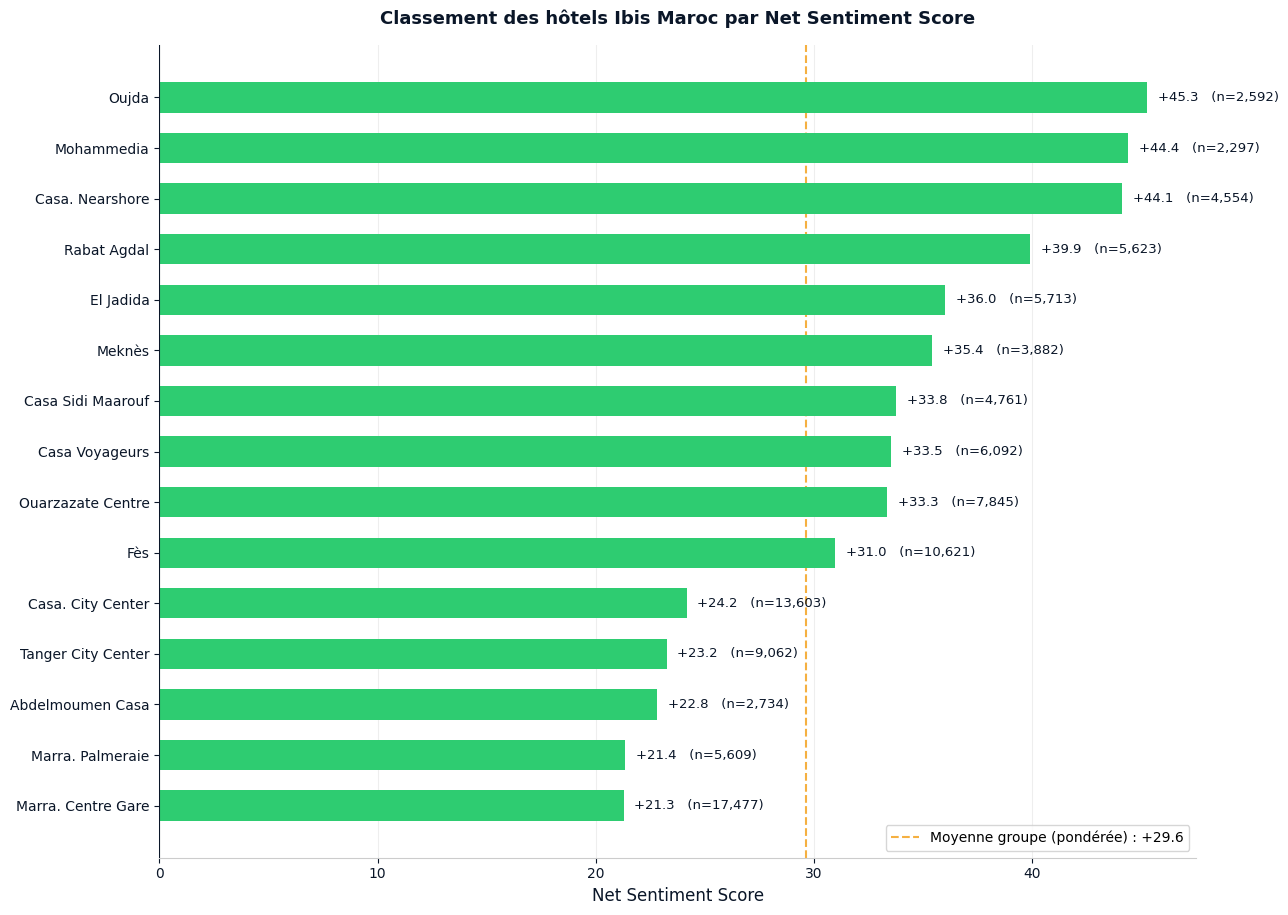

✅ Niveau 1 sauvegardé


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams.update({'font.family': 'DejaVu Sans'})

C_BG  = 'white'; C_TXT = '#0A1628'; C_GRID = '#EEEEEE'; C_SPINE = '#CCCCCC'
C_POS = '#2ECC71'; C_NEG = '#E74C3C'; C_GOLD = '#F39C12'

ASPECT_ORDER = ['personnel','service','chambre_proprete','restauration','localisation',
                'experience','prix','equipements','bruit','temperature','wifi']

def short_hotel(name):
    return (name.replace('Ibis Marrakech ','Ibis Marra. ')
                .replace('Ibis Casablanca ','Ibis Casa. ')
                .replace('Ibis Rabat ','Ibis Rabat ')
                .replace('Ibis ','')
                .strip()[:28])

def nss(grp):
    t = len(grp)
    if t == 0: return np.nan
    return ((grp['sentiment']=='positive').sum() - (grp['sentiment']=='negative').sum()) / t * 100

df_h = df_absa[
    df_absa['aspect'].isin(ASPECT_ORDER) &
    df_absa['sentiment'].isin(['positive','negative','neutral'])
].copy()

hotel_counts = df_h.groupby('hotel_name').size()
hotels_ok    = hotel_counts[hotel_counts >= 200].index.tolist()
df_h         = df_h[df_h['hotel_name'].isin(hotels_ok)]

nss_global = (
    df_h.groupby('hotel_name').apply(nss)
    .reset_index().rename(columns={0:'NSS'})
    .sort_values('NSS', ascending=True)
)
nss_global['hotel_short'] = nss_global['hotel_name'].apply(short_hotel)
nss_global['total']       = nss_global['hotel_name'].map(df_h.groupby('hotel_name').size())

total_pos  = (df_h['sentiment']=='positive').sum()
total_neg  = (df_h['sentiment']=='negative').sum()
nss_groupe = (total_pos - total_neg) / len(df_h) * 100

fig, ax = plt.subplots(figsize=(13, max(6, len(nss_global)*0.55+1)), facecolor=C_BG)
ax.set_facecolor(C_BG)

colors_g = [C_POS if v >= 0 else C_NEG for v in nss_global['NSS']]
bars = ax.barh(nss_global['hotel_short'], nss_global['NSS'],
               color=colors_g, height=0.6, zorder=3)

ax.axvline(0, color=C_TXT, linewidth=1.5, zorder=4)
ax.axvline(nss_groupe, color=C_GOLD, linewidth=1.5, linestyle='--', alpha=0.8,
           label=f"Moyenne groupe (pondérée) : {nss_groupe:+.1f}")

for bar, (_, row) in zip(bars, nss_global.iterrows()):
    v      = row['NSS']
    offset = 0.5 if v >= 0 else -0.5
    ha     = 'left' if v >= 0 else 'right'
    ax.text(v+offset, bar.get_y()+bar.get_height()/2,
            f'{v:+.1f}   (n={int(row["total"]):,})',
            va='center', ha=ha, fontsize=9.5, color=C_TXT)

ax.set_xlabel('Net Sentiment Score', fontsize=12, color=C_TXT)
ax.set_title('Classement des hôtels Ibis Maroc par Net Sentiment Score',
             fontsize=13, fontweight='bold', pad=15, color=C_TXT)
ax.legend(fontsize=10, loc='lower right')
ax.tick_params(colors=C_TXT)
for label in ax.get_xticklabels() + ax.get_yticklabels(): label.set_color(C_TXT)
ax.grid(axis='x', color=C_GRID, linewidth=0.8, zorder=0)
ax.spines[['top','right']].set_visible(False)
ax.spines[['bottom','left']].set_color(C_SPINE)

plt.tight_layout()
plt.savefig('niveau1_classement_hotels.png', dpi=150, bbox_inches='tight', facecolor=C_BG)
plt.show()
print("✅ Niveau 1 sauvegardé")